<a href="https://colab.research.google.com/github/miriyalapranitha94-cell/loan-approval-ml-project/blob/main/Code_of_loan_data1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer # Import SimpleImputer

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [ ]:
# 1. Load Dataset
# ==========================================
data = pd.read_csv("loan_data1.csv")

print("First 5 rows:")
print(data.head())

First 5 rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2     

In [ ]:
print("\nDataset Info:")
print(data.info())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None


In [ ]:
print("\nMissing Values:")
print(data.isnull().sum())



Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


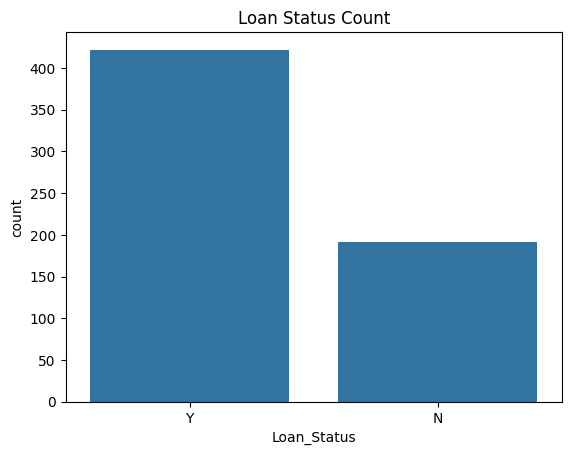

In [ ]:
# 2. EDA (Exploratory Data Analysis)
# ==========================================

# Target Variable Count
plt.figure()
sns.countplot(x='Loan_Status', data=data)
plt.title("Loan Status Count")
plt.show()

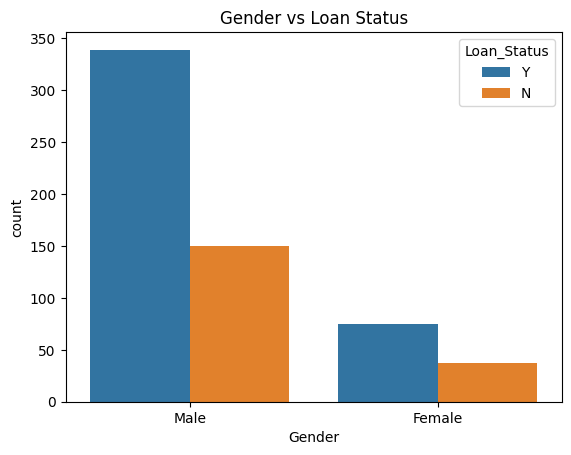

In [ ]:
# Gender vs Loan Status
plt.figure()
sns.countplot(x='Gender', hue='Loan_Status', data=data)
plt.title("Gender vs Loan Status")
plt.show()

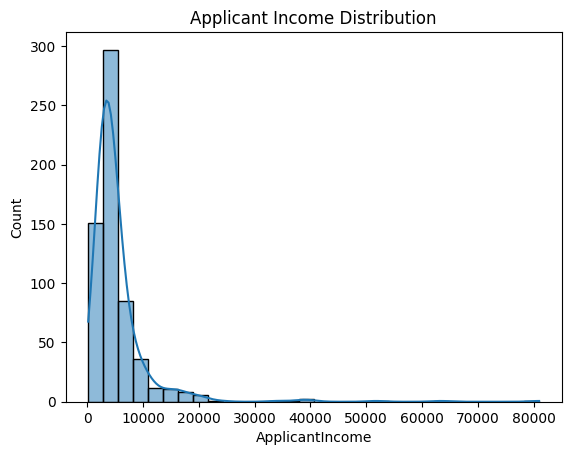

In [ ]:
# Income Distribution
plt.figure()
sns.histplot(data['ApplicantIncome'], bins=30, kde=True)
plt.title("Applicant Income Distribution")
plt.show()


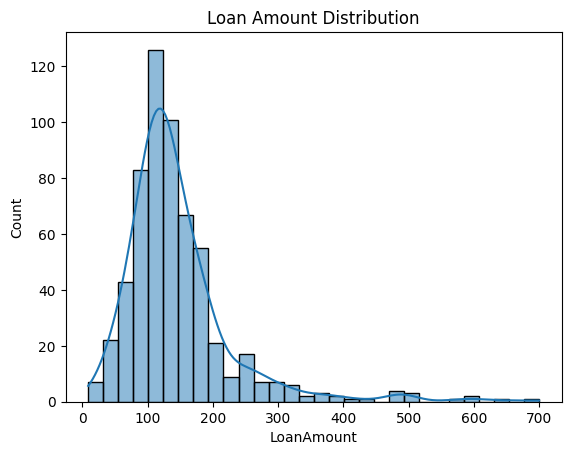

In [ ]:
# Loan Amount Distribution
plt.figure()
sns.histplot(data['LoanAmount'], bins=30, kde=True)
plt.title("Loan Amount Distribution")
plt.show()

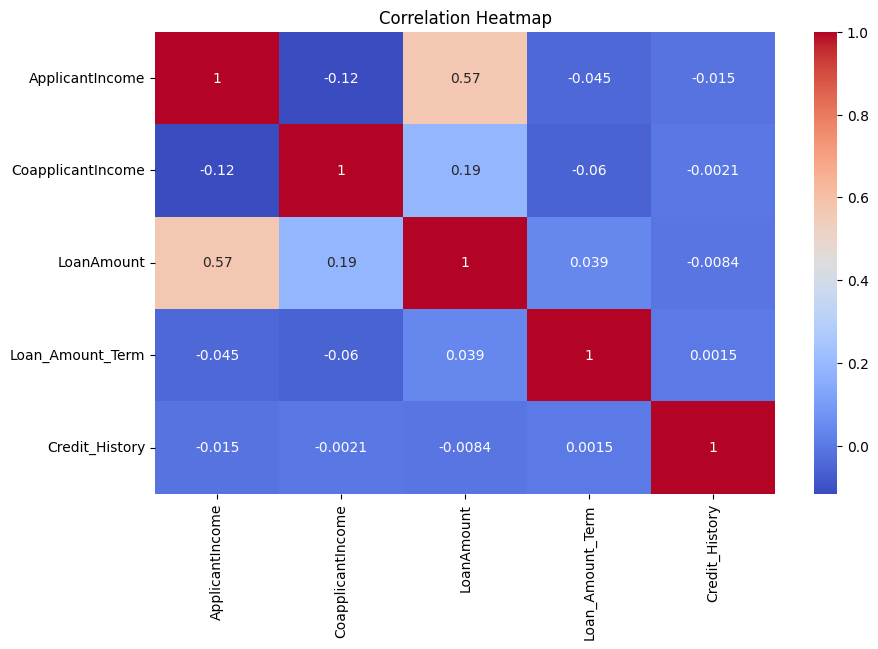

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# 3. Data Preprocessing
# ==========================================

# Handle Missing Values with SimpleImputer (Updated from JU1F_ppO2E_w)
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = data.select_dtypes(include='object').columns

In [ ]:
# Impute numerical columns with the median
imputer_numeric = SimpleImputer(strategy='median')
data[numerical_cols] = imputer_numeric.fit_transform(data[numerical_cols])


In [ ]:
# Impute categorical columns with the most frequent value
imputer_categorical = SimpleImputer(strategy='most_frequent')
for col in categorical_cols:
    if data[col].isnull().any():
        data[col] = imputer_categorical.fit_transform(data[[col]]).ravel()


In [ ]:
# Encode Categorical Data
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

In [ ]:
# 4. Split Data
# ==========================================
X = data.drop("Loan_Status", axis=1)
y = data["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 5. Model Training
# ==========================================

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [ ]:
# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:47:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# 6. Accuracy Results
# ==========================================
print("\n===== Model Accuracies =====")
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))



===== Model Accuracies =====
Decision Tree: 0.6991869918699187
Random Forest: 0.7804878048780488
XGBoost: 0.7560975609756098
Logistic Regression: 0.7886178861788617


In [ ]:
# 7. Classification Report
# ==========================================
print("\n===== XGBoost Report =====")
print(classification_report(y_test, y_pred_xgb))



===== XGBoost Report =====
              precision    recall  f1-score   support

           0       0.74      0.47      0.57        43
           1       0.76      0.91      0.83        80

    accuracy                           0.76       123
   macro avg       0.75      0.69      0.70       123
weighted avg       0.75      0.76      0.74       123



In [ ]:
# 8. Best Model
# ==========================================
accuracies = {
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "XGBoost": accuracy_score(y_test, y_pred_xgb),
    "Logistic Regression": accuracy_score(y_test, y_pred_lr)
}

best_model = max(accuracies, key=accuracies.get)
print("\nBest Model:", best_model)


Best Model: Logistic Regression
